# Proyek Prediksi Analitik: Stroke Dataset
- **Nama:** Herly Riyanto Hidayat
- **Email:** herlynjjd@gmail.com
- **ID Dicoding:** herlyryanth

### Import dependecies

In [1]:
# Import kaggle untuk mengambil data dari kaggle
import kagglehub

# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import pandas as pd
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
import warnings
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Exploratory Dataset

#### Data Loading

In [2]:
source = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

# Define the destination path
destination_path = 'dataset'

# Move the dataset to the destination directory
shutil.copytree(source, destination_path)

print(f"Dataset downloaded and moved to {destination_path}")

Dataset downloaded and moved to dataset


#### Data reading

In [3]:
df = pd.read_csv("/content/dataset/healthcare-dataset-stroke-data.csv")
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


#### Explore the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
# Check the shape of dataframe
print("Shape of dataset: ", df.shape)

Shape of dataset:  (5110, 12)


In [6]:
df.describe(include="all")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


#### Drop irrelevant column

In [7]:
df = df.drop(columns="id")

#### Check Missing Value and Fix it

This section is to check the missing value of the dataset

In [8]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [9]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


From that's output we have conclusion that column bmi have missing value

In [10]:
# Fill the missing value using median
for col in df.columns:
  if df[col].isna().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

In [11]:
df['bmi'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5110 entries, 0 to 5109
Series name: bmi
Non-Null Count  Dtype  
--------------  -----  
5110 non-null   float64
dtypes: float64(1)
memory usage: 40.1 KB


In [12]:
# Check again
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


#### Check the duplicate values and fix it

In [13]:
df.duplicated().sum()

np.int64(0)

#### Check outliers

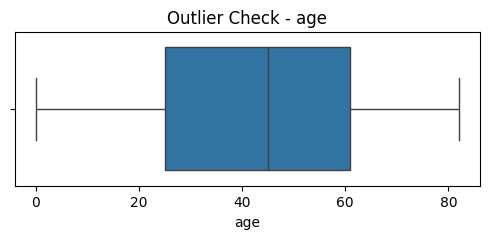

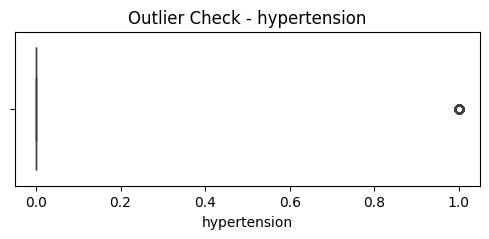

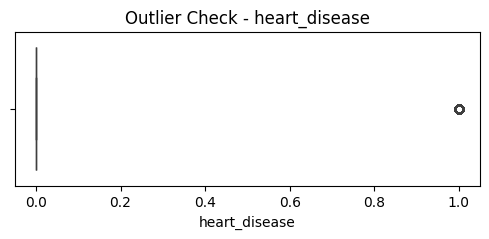

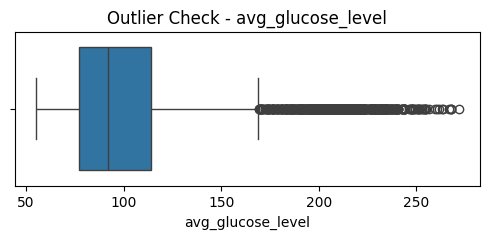

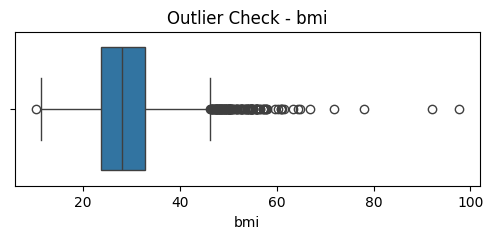

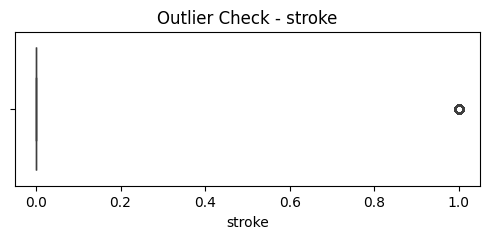

In [14]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
  plt.figure(figsize=(6, 2))
  sns.boxplot(x=df[col])
  plt.title(f'Outlier Check - {col}')
  plt.show()

This dataset have outliers but when we see the column, outliers didn't need to fix, because it's the parameters to decide it's stroke or not

#### Analysis Stroke Patient

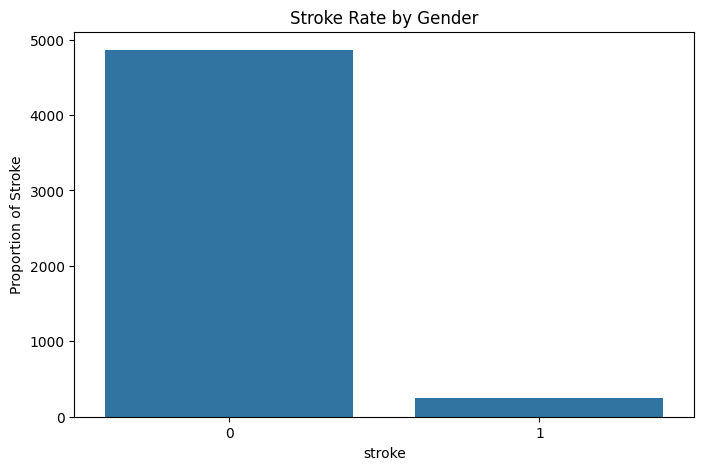

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='stroke', data=df)
plt.title('Stroke Rate by Gender')
plt.ylabel('Proportion of Stroke')
plt.show()

#### Analysis Stroke based on Gender

In [16]:
gender = df['gender'].value_counts()
print(gender)

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


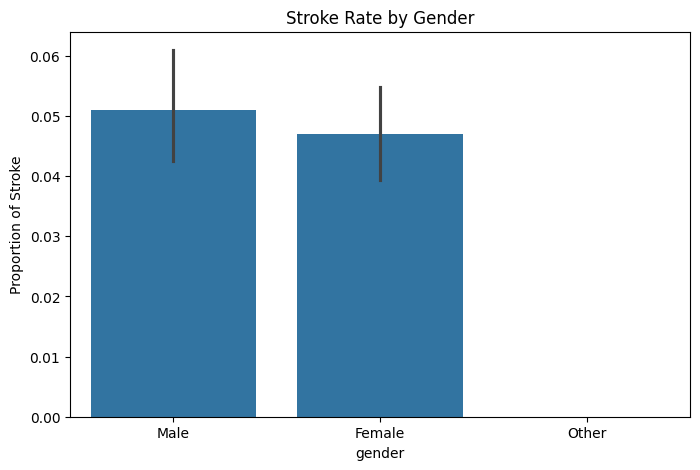

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='stroke', data=df)
plt.title('Stroke Rate by Gender')
plt.ylabel('Proportion of Stroke')
plt.show()

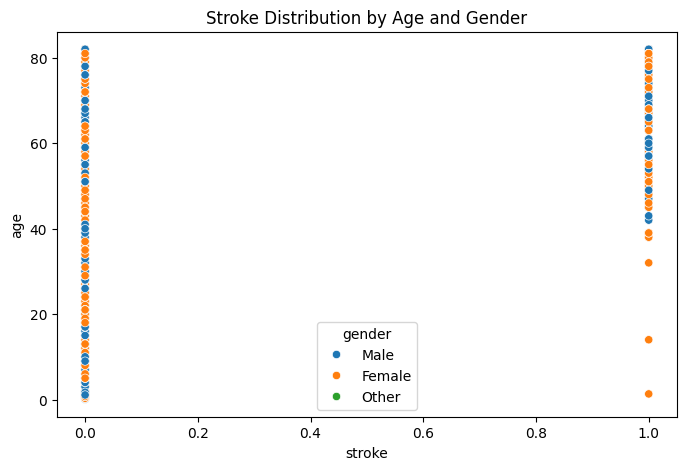

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='stroke', y='age', hue='gender', data=df)
plt.title('Stroke Distribution by Age and Gender')
plt.show()

#### Analysis Stroke based on Smoking Status

In [19]:
smoking_status = df['smoking_status'].value_counts()
smoking_status

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


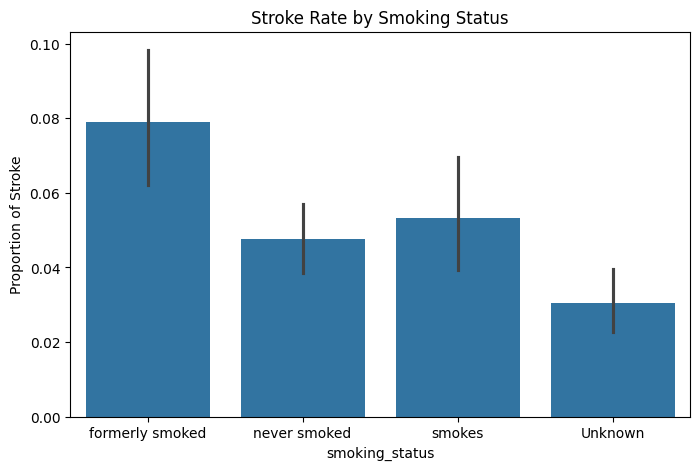

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x='smoking_status', y='stroke', data=df)
plt.title('Stroke Rate by Smoking Status')
plt.ylabel('Proportion of Stroke')
plt.show()

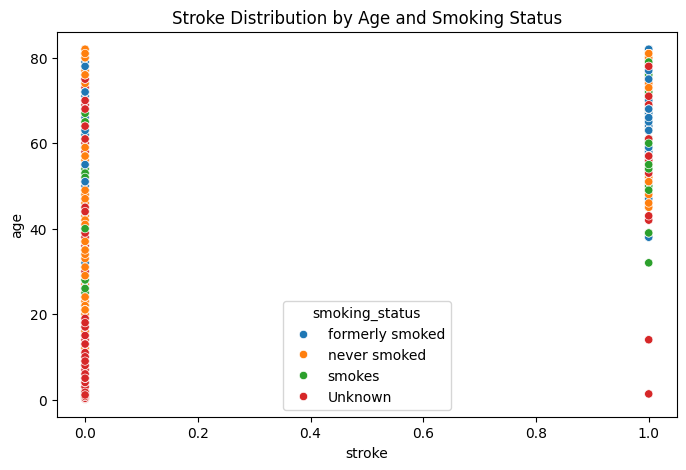

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='stroke', y='age', hue='smoking_status', data=df)
plt.title('Stroke Distribution by Age and Smoking Status')
plt.show()

#### Analysis Correlation numeric features

Text(0.5, 1.0, 'Correlation Matrics for Numeric Features ')

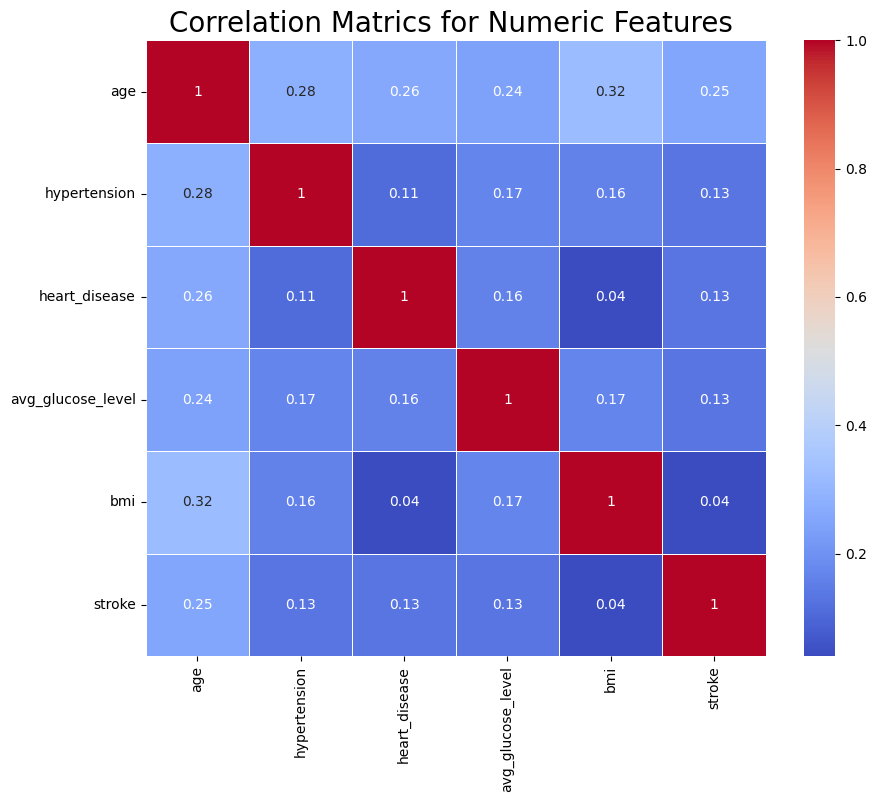

In [22]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[num_cols].corr().round(2)

sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrics for Numeric Features ", size=20)

The numeric features not have correlation with target (stroke)

### Data Preparation

#### Encoding Categorical Features with Label Encoding

In [23]:
df_preprocessed = df.copy()

In [24]:
# Get the categorical features
categorical_cols = df_preprocessed.select_dtypes(include='object').columns
categorical_cols

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

In [25]:
for col in categorical_cols:
  le= LabelEncoder()
  df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
df_preprocessed.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [26]:
df_preprocessed.corr().round(2)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.00,-0.03,0.02,0.09,-0.03,0.06,-0.01,0.06,-0.03,-0.06,0.01
age,-0.03,1.00,0.28,0.26,0.68,-0.36,0.01,0.24,0.32,0.27,0.25
hypertension,0.02,0.28,1.00,0.11,0.16,-0.05,-0.01,0.17,0.16,0.11,0.13
heart_disease,0.09,0.26,0.11,1.00,0.11,-0.03,0.00,0.16,0.04,0.05,0.13
ever_married,-0.03,0.68,0.16,0.11,1.00,-0.35,0.01,0.16,0.33,0.26,0.11
work_type,0.06,-0.36,-0.05,-0.03,-0.35,1.00,-0.01,-0.05,-0.30,-0.31,-0.03
Residence_type,-0.01,0.01,-0.01,0.00,0.01,-0.01,1.00,-0.00,-0.00,0.01,0.02
avg_glucose_level,0.06,0.24,0.17,0.16,0.16,-0.05,-0.00,1.00,0.17,0.06,0.13
bmi,-0.03,0.32,0.16,0.04,0.33,-0.30,-0.00,0.17,1.00,0.22,0.04
smoking_status,-0.06,0.27,0.11,0.05,0.26,-0.31,0.01,0.06,0.22,1.00,0.03


#### Split Features and Target

In [27]:
# Split features and target to Standardization
feature = df_preprocessed.drop(columns=['stroke'])
target = df_preprocessed['stroke']

#### Standardization using StandardScaler()

In [28]:
# Data Transformation
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(feature), columns=feature.columns)
data_scaled['stroke'] = target

In [29]:
data_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.188073,1.051434,-0.328602,4.185032,0.723884,-0.153836,0.984080,2.706375,1.005086,-0.351781,1
1,-0.840344,0.786070,-0.328602,-0.238947,0.723884,0.763438,-1.016178,2.121559,-0.098981,0.581552,1
2,1.188073,1.626390,-0.328602,4.185032,0.723884,-0.153836,-1.016178,-0.005028,0.472536,0.581552,1
3,-0.840344,0.255342,-0.328602,-0.238947,0.723884,-0.153836,0.984080,1.437358,0.719327,1.514885,1
4,-0.840344,1.582163,3.043196,-0.238947,0.723884,0.763438,-1.016178,1.501184,-0.631531,0.581552,1


#### Data Splitting

In [30]:
# Split X (features) = all column except stroke, y (target) = stroke column
X = data_scaled.drop(columns=['stroke'])
y = data_scaled['stroke']

In [31]:
# Resampling Data using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [32]:
# Splitting into Train (70%), Validation (15%), and Test Sets (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Modelling

In [33]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [34]:
# XGB Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Suppress warnings before fitting the XGBoost model
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:07:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [35]:
# Deep Learning using Fully Connected Layer or Dense Neural Network (DNN)
model_dl = Sequential([
    Dense(32, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # output 1 neuron for binary classification
])

In [36]:
model_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = model_dl.fit(X_train, y_train, epochs=10, batch_size=4, validation_data=(X_val, y_val))

Epoch 1/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7550 - loss: 0.4960 - val_accuracy: 0.8045 - val_loss: 0.4213
Epoch 2/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7979 - loss: 0.4293 - val_accuracy: 0.8189 - val_loss: 0.3989
Epoch 3/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8128 - loss: 0.4047 - val_accuracy: 0.8251 - val_loss: 0.3908
Epoch 4/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8237 - loss: 0.3850 - val_accuracy: 0.8347 - val_loss: 0.3752
Epoch 5/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8364 - loss: 0.3676 - val_accuracy: 0.8374 - val_loss: 0.3629
Epoch 6/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8419 - loss: 0.3548 - val_accuracy: 0.8395 - val_loss: 0.3549
Epoch 7/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8279 - loss: 0.3685 - val_accuracy: 0.8443 - val_loss: 0.3555
Epoch 8/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8502 - loss: 0.3353 

### Evaluation

In [38]:
# Evaluation function
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    cr = classification_report(y_test, y_pred)
    print(f"{name} Evaluation:\nAccuracy: {accuracy}\nClassification Report: \n{cr}")

In [39]:
evaluate_model("Random Forest Classifier", y_test, rf_preds)

Random Forest Classifier Evaluation:
Accuracy: 0.9568197395476353
Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       749
           1       0.95      0.96      0.96       710

    accuracy                           0.96      1459
   macro avg       0.96      0.96      0.96      1459
weighted avg       0.96      0.96      0.96      1459



In [40]:
evaluate_model("XGB Classifier", y_test, xgb_preds)

XGB Classifier Evaluation:
Accuracy: 0.9561343385880741
Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       749
           1       0.97      0.94      0.95       710

    accuracy                           0.96      1459
   macro avg       0.96      0.96      0.96      1459
weighted avg       0.96      0.96      0.96      1459



In [41]:
loss, accuracy = model_dl.evaluate(X_test, y_test)
print('Test Accuracy:', accuracy)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8362 - loss: 0.3852
Test Accuracy: 0.8498972058296204


#### Hyperparameter Tuning for model Accuracy below 90%

In [47]:
!pip install keras-tuner -q
import keras_tuner as kt

def model_builder(hp):
  model = Sequential()
  model.add(Dense(units=hp.Int('units', min_value=32, max_value=128, step=32), activation='relu', input_shape=(X_train.shape[1],)))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model

tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
model_dl=tuner.hypermodel.build(best_hps)
history = model_dl.fit(X_train, y_train, epochs=10, batch_size=4, validation_data=(X_val, y_val))

Trial 11 Complete [00h 00m 04s]
val_accuracy: 0.8120713233947754

Best val_accuracy So Far: 0.8333333134651184
Total elapsed time: 00h 00m 45s
Epoch 1/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7878 - loss: 0.4649 - val_accuracy: 0.7894 - val_loss: 0.4371
Epoch 2/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8068 - loss: 0.4147 - val_accuracy: 0.8306 - val_loss: 0.3751
Epoch 3/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8089 - loss: 0.4065 - val_accuracy: 0.8326 - val_loss: 0.3578
Epoch 4/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8317 - loss: 0.3697 - val_accuracy: 0.8381 - val_loss: 0.3659
Epoch 5/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8242 - loss: 0.3652 - val_accuracy: 0.8560 - val_loss: 0.3364
Epoch 6/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8533 - loss: 0.3372 - val_accuracy: 0.8326 - val_loss: 0.3458
Epoch 7/10
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8531 - lo

In [48]:
loss, accuracy = model_dl.evaluate(X_test, y_test)
print('Test Accuracy:', accuracy)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8479 - loss: 0.3410
Test Accuracy: 0.8553804159164429


After doing Hyperparameter I got accuracy increase from 85% to 85,6%

### Testing

In [49]:
# Create dictionary to save all model
model_dict = {'RandomForestClassiier': rf_model, 'XGBClassifier': xgb_model, 'DNN':model_dl}

In [50]:
# Get one sample data from X_test
data = X_test.iloc[:1].copy()

# Create a dictionary to save the predict of all model
pred_dict = {'y_true (nilai aktual)': y_test.iloc[:1].values}

# Variable to save prediction from convert the 0/1 label
convert_pred_label = ""
# Loop all model from model_dict
for name, model in model_dict.items():
    # Predict the probability
    pred = model.predict(data)

    # If the predict is array 2D, convert it to 1D
    if pred.ndim > 1:
        pred = pred.flatten()

    # For biner classification, change the probability to 0/1 label
    pred_label = (pred >= 0.5).astype(int)
    if pred_label == 0:
      convert_pred_label = "The patient not have probability stroke"
    else:
      convert_pred_label = "The patient have probability stroke"

    # Save the result of prediction model
    pred_dict['prediksi_' + name] = pred_label

# Show the dataframe predict
print(convert_pred_label)
pd.DataFrame(pred_dict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
The patient have probability stroke


,y_true (nilai aktual),prediksi_RandomForestClassiier,prediksi_XGBClassifier,prediksi_DNN
0,1,1,1,1
